In [1]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate dataset
X, y = make_classification(
    n_samples=1000,      # Number of rows
    n_features=2,       # Number of features (good for visualization)
    n_informative=2,    # Useful features
    n_redundant=0,      # No redundant features
    n_repeated=0,
    n_classes=2,        # Binary classification
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Target"] = y

print(df.head())

   Feature1  Feature2  Target
0  2.477879 -2.342875       1
1 -0.698962 -0.127490       0
2 -1.103789  0.806016       0
3  1.294046 -1.308141       1
4 -0.923347  1.145205       0


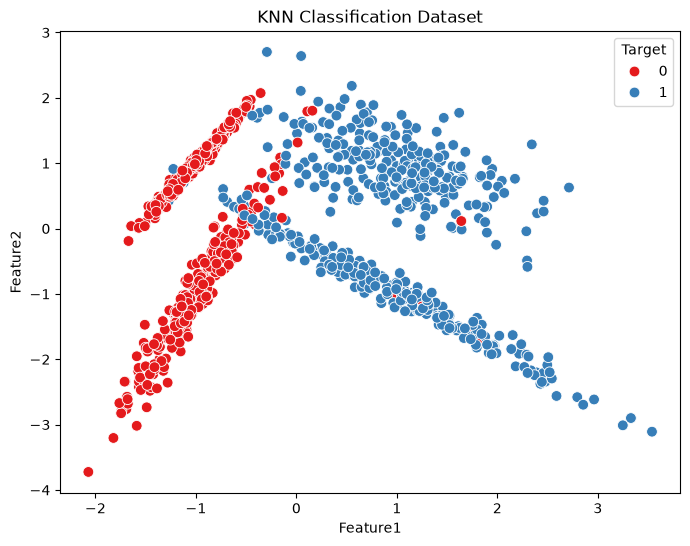

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Target",
    palette="Set1",
    s=60
)

plt.title("KNN Classification Dataset")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

X = df[["Feature1", "Feature2"]]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

# Scores
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

"""
dt = DecisionTreeClassifier(
    criterion="gini",     # or "entropy", "log_loss"
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
) """

Accuracy : 0.945
Precision: 0.97
Recall   : 0.9238095238095239
F1 Score : 0.9463414634146341

Confusion Matrix
[[92  3]
 [ 8 97]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        95
           1       0.97      0.92      0.95       105

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200

